# Drzewo decyzyjne

## Zadanie na 3

Implementacja drzewa decyzyjnego

#### Import bibliotek

In [228]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from scipy.io import arff
from sklearn.model_selection import GridSearchCV
import time
from collections import Counter

#### Funkcje do oceny skuteczności 

In [229]:
def plot_confusion_matrix(y_true, y_pred, labels=None):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Macierz Pomyłek")
    plt.show()

def calculate_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    return accuracy, sensitivity, specificity

def plot_roc_curve(y_true, y_scores):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Losowa klasyfikacja')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('Krzywa ROC')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                             np.arange(y_min, y_max, 0.01))
        
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
        
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap='viridis', s=50)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.show()

### Wygenerowanie danych

Jednomodowe - make_classification

In [230]:
my_index = 259199
my_n_samples = int(str(my_index)[0]+ str(my_index)[1] + str(my_index)[-2] + str(my_index)[-1])
X_classification, y_classification = make_classification(
    n_samples=my_n_samples, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_clusters_per_class=1, 
    random_state=my_index,
)

print('x', X_classification.shape)
print('y', y_classification.shape)

x (2599, 2)
y (2599,)


Jednomodowe - make_moons

In [231]:
X_moons, y_moons = make_moons(n_samples=my_n_samples, noise=0.2, random_state=my_index)

print('X_moons', X_moons.shape)
print('y_moons', y_moons.shape)

X_moons (2599, 2)
y_moons (2599,)


Wielomodowy - make_blobs

In [232]:
n_features = 2    
n_classes = 2     
n_clusters_per_class = 2

X_blobs, y_blobs = make_blobs(
    n_samples=my_n_samples,
    centers=n_classes * n_clusters_per_class,
    n_features=n_features,
    random_state=my_index
)

y_blobs = y_blobs % n_classes

print('X_blobs', X_blobs.shape)
print('y_blobs', y_blobs.shape)

X_blobs (2599, 2)
y_blobs (2599,)


#### Podział danych na treningowe i testowe

In [233]:
X_classification_train, X_classification_test, y_classification_train, y_classification_test = train_test_split(
    X_classification, y_classification, test_size=0.2, random_state=my_index
)

X_moons_train, X_moons_test, y_moons_train, y_moons_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=my_index
)

X_blobs_train, X_blobs_test, y_blobs_train, y_blobs_test = train_test_split(
    X_blobs, y_blobs, test_size=0.2, random_state=my_index
)

print("classification:", X_classification_train.shape, y_classification_train.shape, X_classification_test.shape, y_classification_test.shape)
print("nmoons:", X_moons_train.shape, y_moons_train.shape, X_moons_test.shape, y_moons_test.shape)
print("blobs:", X_blobs_train.shape, y_blobs_train.shape, X_blobs_test.shape, y_blobs_test.shape)


classification: (2079, 2) (2079,) (520, 2) (520,)
nmoons: (2079, 2) (2079,) (520, 2) (520,)
blobs: (2079, 2) (2079,) (520, 2) (520,)


### Własna implementacja drzewa decyzyjnego

In [234]:
class DecisionTree:
    class TreeNode:
        def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
            self.feature_index = feature_index  
            self.threshold = threshold          
            self.left = left                    
            self.right = right                  
            self.value = value                  

    def __init__(self, max_depth=None):
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        self.n_classes_ = len(np.unique(y))
        self.n_features_ = X.shape[1]
        self.root = self._grow_tree(X, y, depth=0)

    def _grow_tree(self, X, y, depth):
        num_samples = len(y)
        num_classes = len(np.unique(y))

        if num_classes == 1 or num_samples == 0:
            return self.TreeNode(value=y[0] if len(y) > 0 else None)
        if self.max_depth is not None and depth >= self.max_depth:
            majority_class = Counter(y).most_common(1)[0][0]
            return self.TreeNode(value=majority_class)

        best_feature, best_threshold = self._find_best_split(X, y)
        if best_feature is None:
            majority_class = Counter(y).most_common(1)[0][0]
            return self.TreeNode(value=majority_class)

        left_mask = X[:, best_feature] <= best_threshold
        right_mask = ~left_mask

        left_subtree = self._grow_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._grow_tree(X[right_mask], y[right_mask], depth + 1)

        return self.TreeNode(feature_index=best_feature, threshold=best_threshold,
                             left=left_subtree, right=right_subtree)

    def _entropy(self, y):
        counts = np.bincount(y, minlength=self.n_classes_)
        probabilities = counts / len(y)
        probabilities = probabilities[probabilities > 0]
        return -np.sum(probabilities * np.log2(probabilities))

    def _information_gain(self, y, feature_values, threshold):
        parent_entropy = self._entropy(y)

        left_mask = feature_values <= threshold
        right_mask = ~left_mask

        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return 0

        left_entropy = self._entropy(y[left_mask])
        right_entropy = self._entropy(y[right_mask])

        n = len(y)
        n_left = np.sum(left_mask)
        n_right = np.sum(right_mask)

        weighted_entropy = (n_left / n) * left_entropy + (n_right / n) * right_entropy
        return parent_entropy - weighted_entropy

    def _find_best_split(self, X, y):
        best_gain = -1
        best_feature = None
        best_threshold = None

        for feature_index in range(self.n_features_):
            values = X[:, feature_index]
            thresholds = np.percentile(values, np.arange(10, 100, 10))
            thresholds = np.unique(thresholds)

            for threshold in thresholds:
                gain = self._information_gain(y, values, threshold)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature_index
                    best_threshold = threshold

        return best_feature, best_threshold

    def _traverse(self, x, node):
            while node.value is None:
                if x[node.feature_index] <= node.threshold:
                    node = node.left
                else:
                    node = node.right
            return node.value

    def predict(self, X):
        return np.array([self._traverse(sample, self.root) for sample in X])

#### Porównanie czasów

In [235]:
start_time = time.time()

for _ in range(10):
    clf_classification = DecisionTree()
    clf_classification.fit(X_classification_train, y_classification_train)

end_time = time.time()

print(f"MyDecisionTree - czas dla 10 iteracji: {end_time - start_time:.2f} s")

start_time = time.time()

for _ in range(10):
    clf_classification = DecisionTreeClassifier(random_state=my_index)
    clf_classification.fit(X_classification_train, y_classification_train)

end_time = time.time()

print(f"DecisionTreeClassifier - czas dla 10 iteracji: {end_time - start_time:.2f} s")

MyDecisionTree - czas dla 10 iteracji: 3.63 s
DecisionTreeClassifier - czas dla 10 iteracji: 0.04 s


#### Porównanie wyników 

Własna implementacja

classification
Accuracy: 0.91, Sensitivity: 0.89, Specificity: 0.92


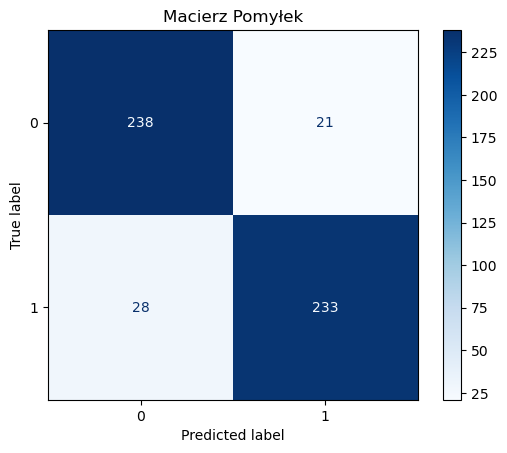

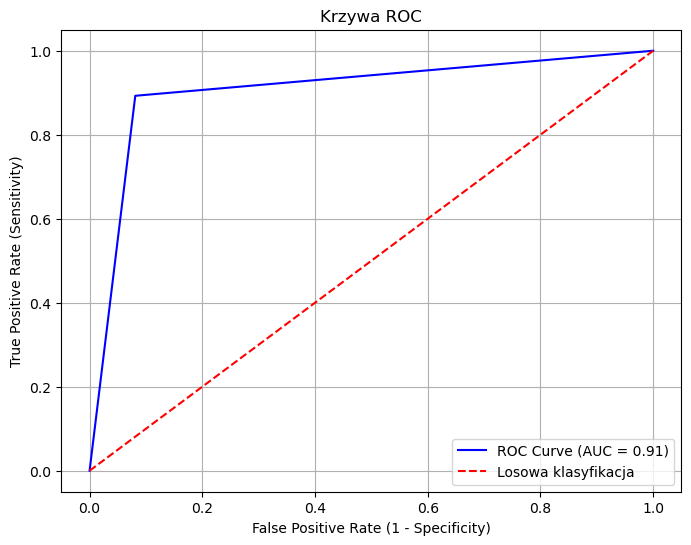

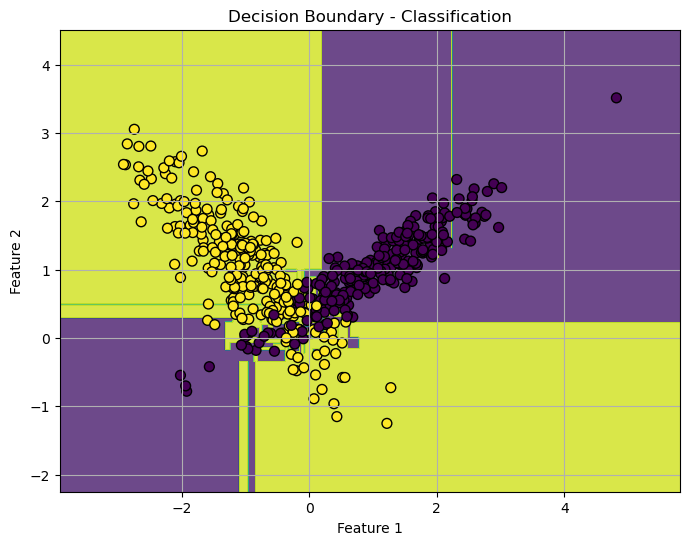

moons
Accuracy: 0.97, Sensitivity: 0.97, Specificity: 0.97


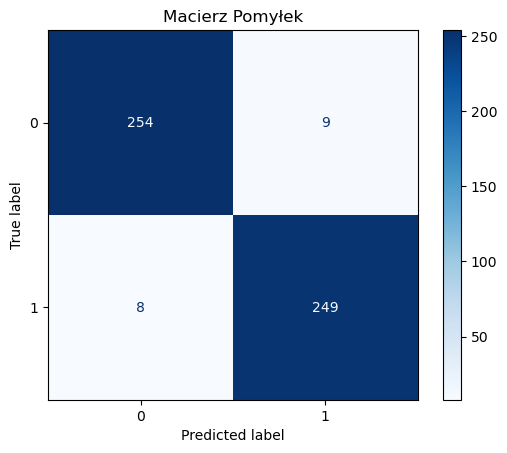

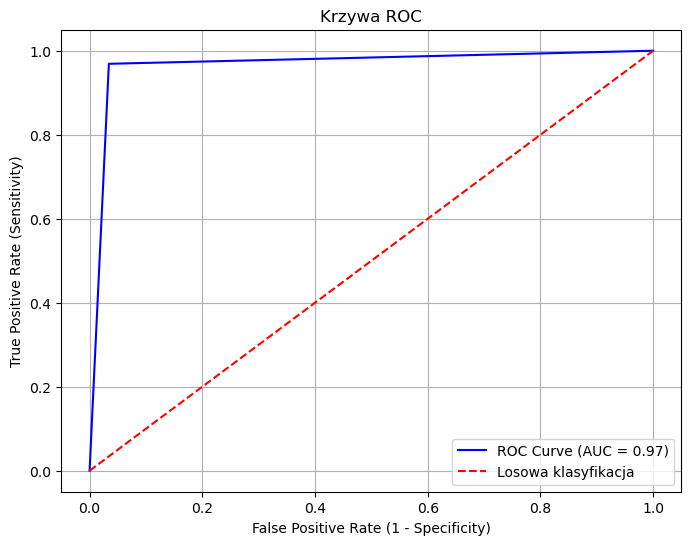

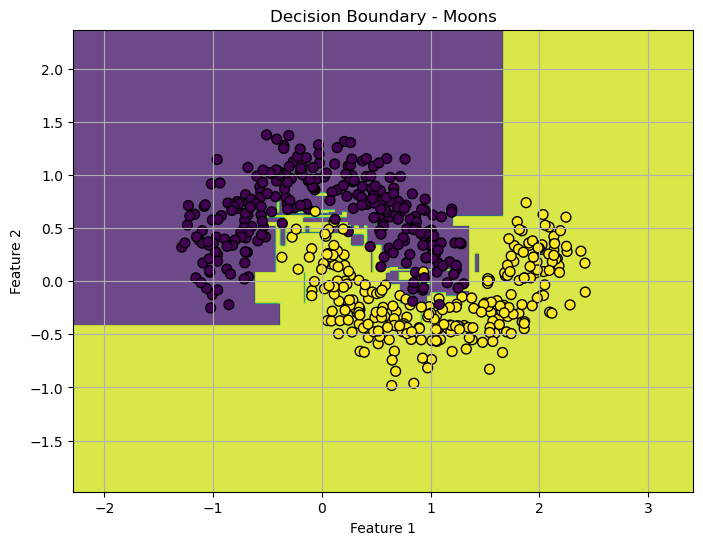

blobs
Accuracy: 0.86, Sensitivity: 0.85, Specificity: 0.87


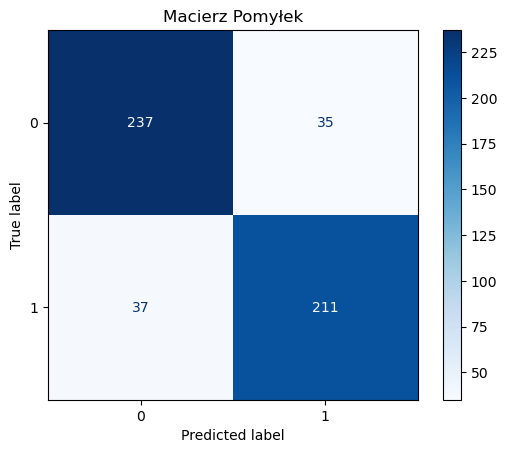

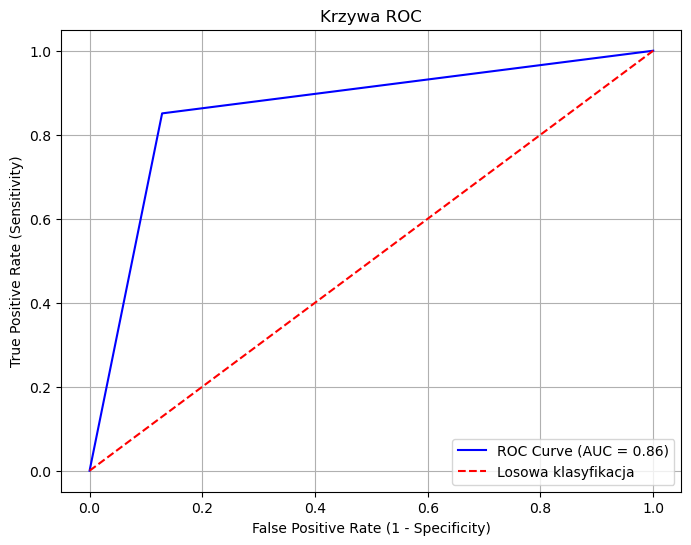

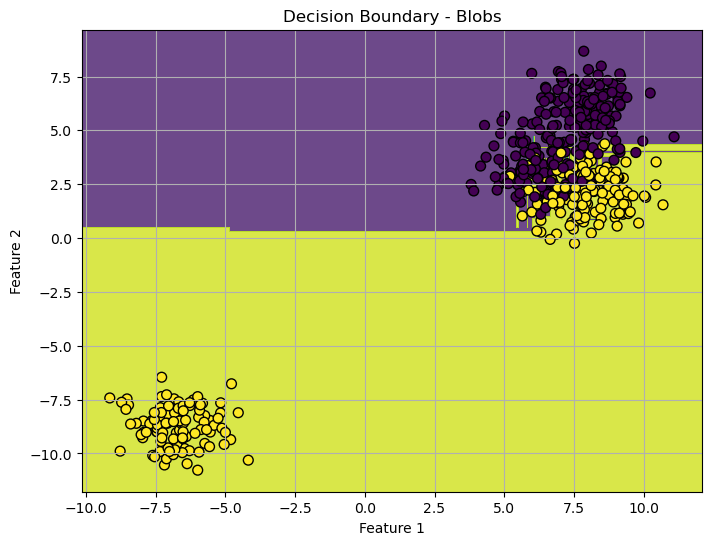

In [236]:
results = pd.DataFrame(columns=["Accuracy", "Sensitivity", "Specificity"])

clf_classification = DecisionTree()
clf_classification.fit(X_classification_train, y_classification_train)
y_classification_pred = clf_classification.predict(X_classification_test)

print("classification")
accuracy, sensitivity, specificity = calculate_metrics(y_classification_test, y_classification_pred)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["myTree - classification"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_classification_test, y_classification_pred, labels=["0", "1"])
plot_roc_curve(y_classification_test, y_classification_pred)
plot_decision_boundary(clf_classification, X_classification_test, y_classification_test, title="Decision Boundary - Classification")

clf_moons = DecisionTree()
clf_moons.fit(X_moons_train, y_moons_train)
y_moons_pred = clf_moons.predict(X_moons_test)

print("moons")
accuracy, sensitivity, specificity = calculate_metrics(y_moons_test, y_moons_pred)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["myTree - moons"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_moons_test, y_moons_pred, labels=["0", "1"])
plot_roc_curve(y_moons_test, y_moons_pred)
plot_decision_boundary(clf_moons, X_moons_test, y_moons_test, title="Decision Boundary - Moons")

clf_blobs = DecisionTree()
clf_blobs.fit(X_blobs_train, y_blobs_train)
y_blobs_pred = clf_blobs.predict(X_blobs_test)

print("blobs")
accuracy, sensitivity, specificity = calculate_metrics(y_blobs_test, y_blobs_pred)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["myTree - blobs"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_blobs_test, y_blobs_pred, labels=["0", "1"])
plot_roc_curve(y_blobs_test, y_blobs_pred)
plot_decision_boundary(clf_blobs, X_blobs_test, y_blobs_test, title="Decision Boundary - Blobs")

DecisionTreeClassifier

classification
Accuracy: 0.88, Sensitivity: 0.85, Specificity: 0.92


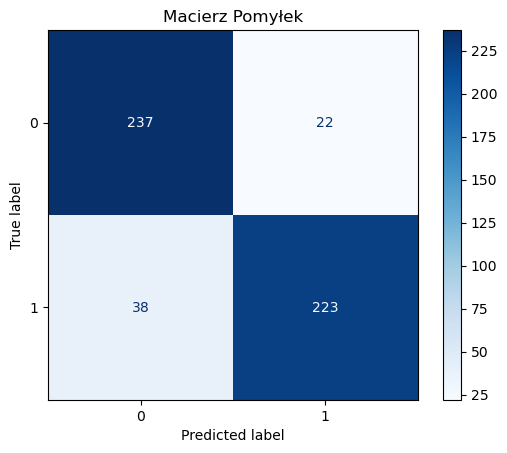

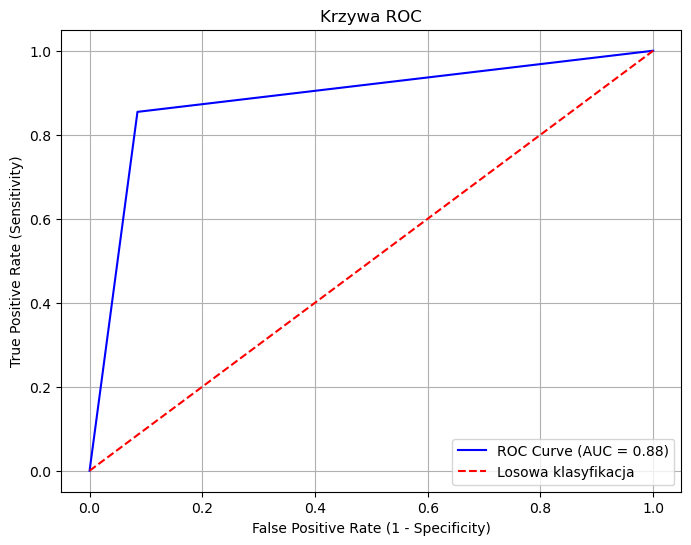

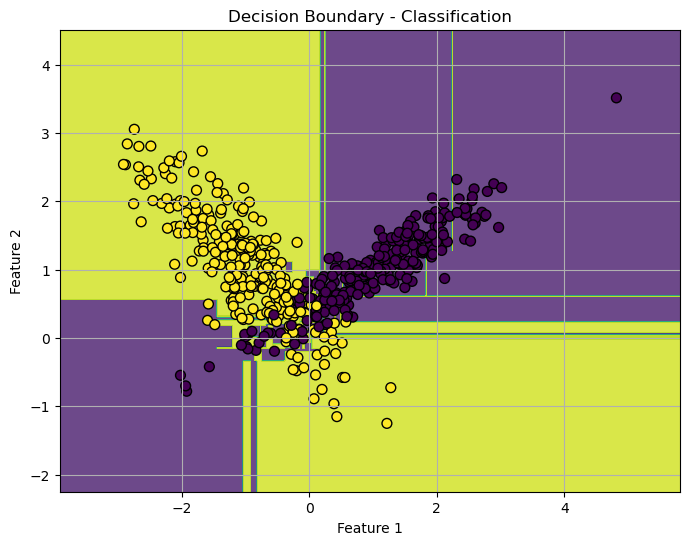

moons
Accuracy: 0.98, Sensitivity: 0.98, Specificity: 0.98


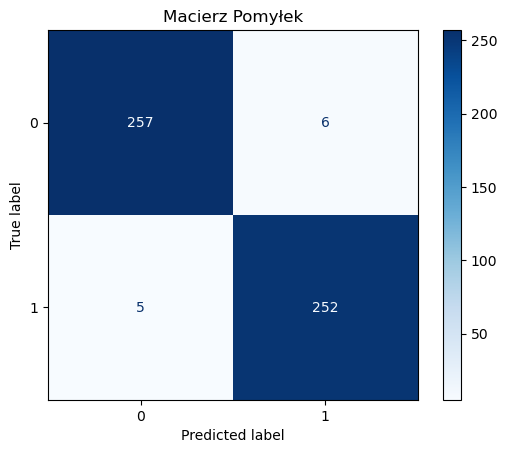

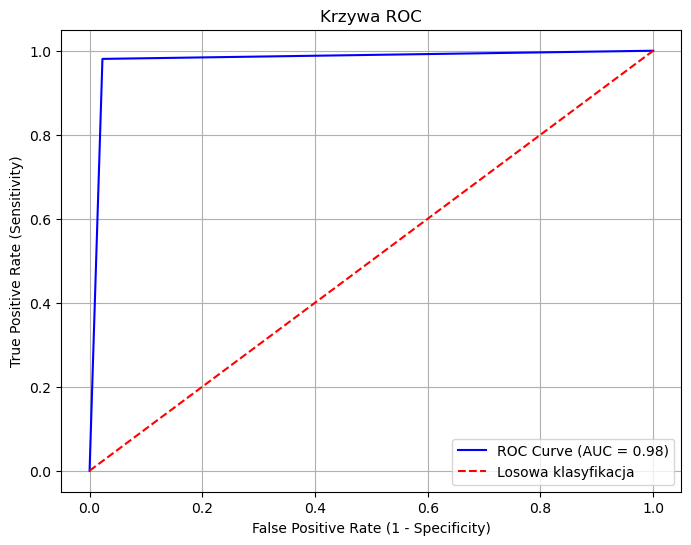

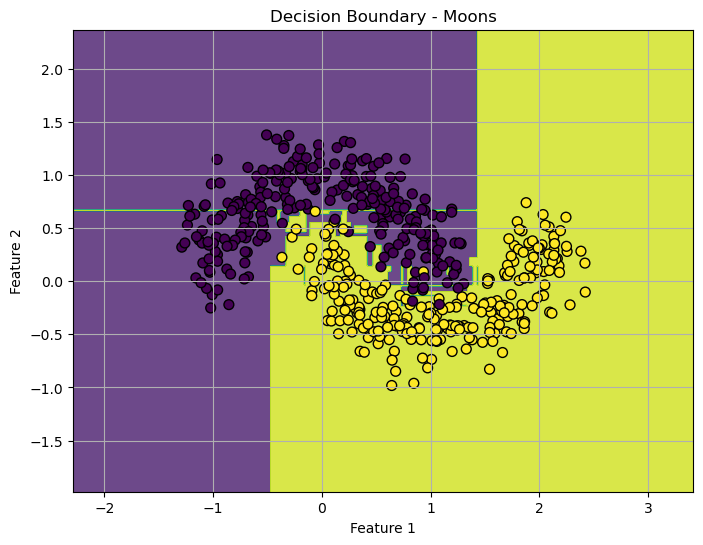

blobs
Accuracy: 0.86, Sensitivity: 0.84, Specificity: 0.89


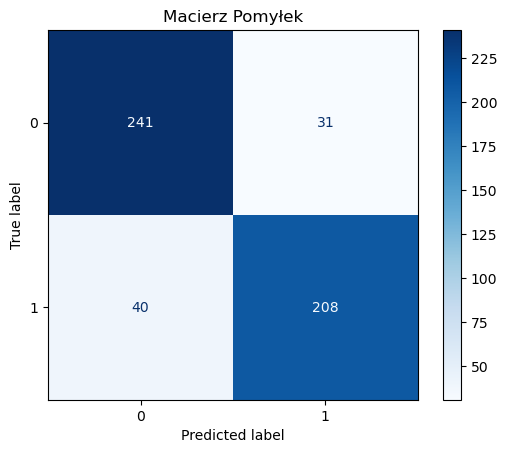

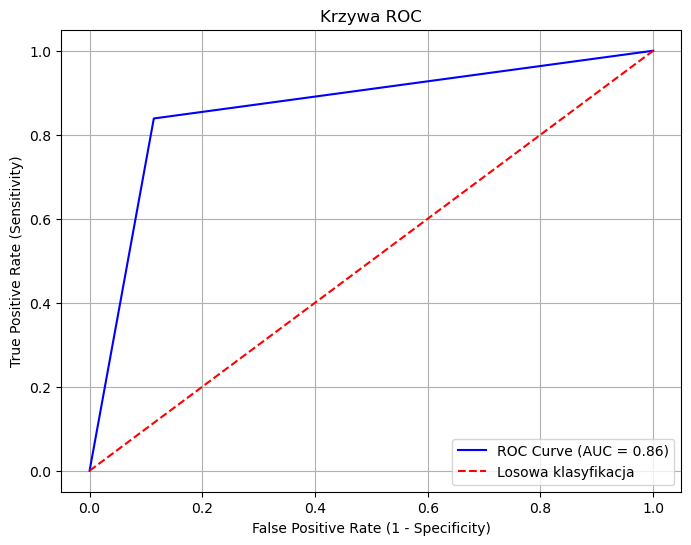

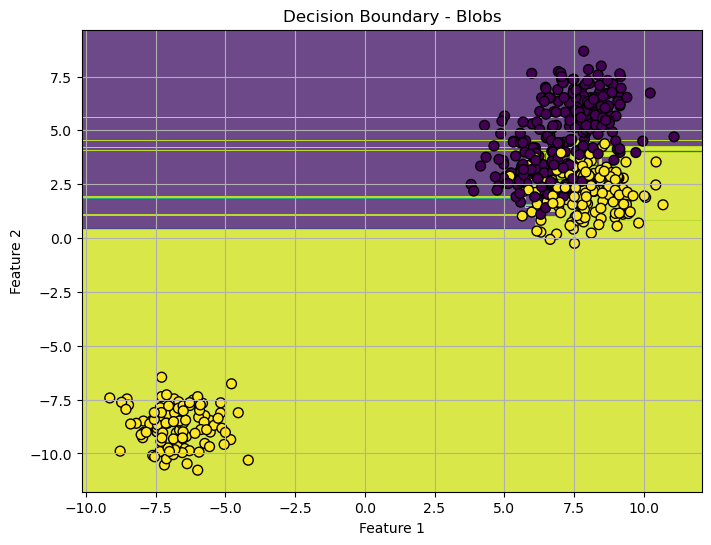

In [237]:
clf_classification = DecisionTreeClassifier(random_state=my_index)
clf_classification.fit(X_classification_train, y_classification_train)
y_pred_classification = clf_classification.predict(X_classification_test)

print("classification")
accuracy, sensitivity, specificity = calculate_metrics(y_classification_test, y_pred_classification)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["sklearn - classification"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_classification_test, y_pred_classification)
plot_roc_curve(y_classification_test, y_pred_classification)
plot_decision_boundary(clf_classification, X_classification_test, y_classification_test, title="Decision Boundary - Classification")

clf_moons = DecisionTreeClassifier(random_state=my_index)
clf_moons.fit(X_moons_train, y_moons_train)
y_pred_moons = clf_moons.predict(X_moons_test)

print("moons")
accuracy, sensitivity, specificity = calculate_metrics(y_moons_test, y_pred_moons)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["sklearn - moons"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_moons_test, y_pred_moons)
plot_roc_curve(y_moons_test, y_pred_moons)
plot_decision_boundary(clf_moons, X_moons_test, y_moons_test, title="Decision Boundary - Moons")

clf_blobs = DecisionTreeClassifier(random_state=my_index)
clf_blobs.fit(X_blobs_train, y_blobs_train)
y_pred_blobs = clf_blobs.predict(X_blobs_test)

print("blobs")
accuracy, sensitivity, specificity = calculate_metrics(y_blobs_test, y_pred_blobs)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
results.loc["sklearn - blobs"] = [accuracy, sensitivity, specificity]
plot_confusion_matrix(y_blobs_test, y_pred_blobs)
plot_roc_curve(y_blobs_test, y_pred_blobs)
plot_decision_boundary(clf_blobs, X_blobs_test, y_blobs_test, title="Decision Boundary - Blobs")

In [238]:
pd.DataFrame(results)

,Accuracy,Sensitivity,Specificity
myTree - classification,0.905769,0.892720,0.918919
myTree - moons,0.967308,0.968872,0.965779
myTree - blobs,0.861538,0.850806,0.871324
sklearn - classification,0.884615,0.854406,0.915058
sklearn - moons,0.978846,0.980545,0.977186
sklearn - blobs,0.863462,0.838710,0.886029


## Zadanie na 4

Analiza zbioru HTRU2 w oparciu o drzewo decyzyjne

#### Wczytanie danych 

In [239]:
file_path = f'./Datasets\HTRU2\HTRU_2.arff'
data_arff, meta = arff.loadarff(file_path)
data = pd.DataFrame(data_arff)

print(data.shape)
data.head()

(17898, 9)


,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis,class
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,b'0'
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,b'0'
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,b'0'
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,b'0'
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,b'0'


#### Podział na X i Y

In [240]:
X = data.drop(columns=['class'])
y = data['class'].apply(lambda x: int(x == b'1'))

print(X.shape, y.shape)
print(np.unique(y))

(17898, 8) (17898,)
[0 1]


#### Sprawdzenie czy nie ma brakujących wartości

In [241]:
print(data.isnull().sum())

Profile_mean        0
Profile_stdev       0
Profile_skewness    0
Profile_kurtosis    0
DM_mean             0
DM_stdev            0
DM_skewness         0
DM_kurtosis         0
class               0
dtype: int64


In [242]:
scaler = MinMaxScaler()
new_X = scaler.fit_transform(X)

X = pd.DataFrame(new_X, columns=X.columns)

X.head()

,Profile_mean,Profile_stdev,Profile_skewness,Profile_kurtosis,DM_mean,DM_stdev,DM_skewness,DM_kurtosis
0,0.721342,0.417687,0.165043,0.015627,0.013382,0.113681,0.294986,0.063890
1,0.517628,0.460908,0.235415,0.018268,0.006560,0.072524,0.364015,0.108443
2,0.520346,0.196868,0.221138,0.040677,0.013030,0.139188,0.288624,0.054610
3,0.700933,0.437884,0.181750,0.016534,0.015368,0.131583,0.266348,0.046581
4,0.443854,0.214847,0.249044,0.041712,0.004327,0.039684,0.462029,0.213369


#### Podział danych na treningowe i testowe

In [243]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=my_index, stratify=y)

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(14318, 8) (14318,) (3580, 8) (3580,)


#### Dobór odpowiednich hiperparametrów

In [244]:
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}


dtc = DecisionTreeClassifier(random_state=my_index)
grid_search = GridSearchCV(dtc, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Najlepsze parametry:", grid_search.best_params_)
print("Najlepszy wynik cross-val:", grid_search.best_score_)

Najlepsze parametry: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10}
Najlepszy wynik cross-val: 0.9796762586418513


#### Uczenie drzewa dla wybranych hiperparametrów

Accuracy: 0.98, Sensitivity: 0.83, Specificity: 0.99


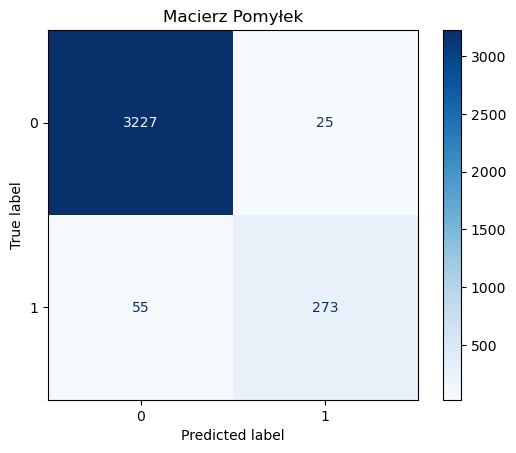

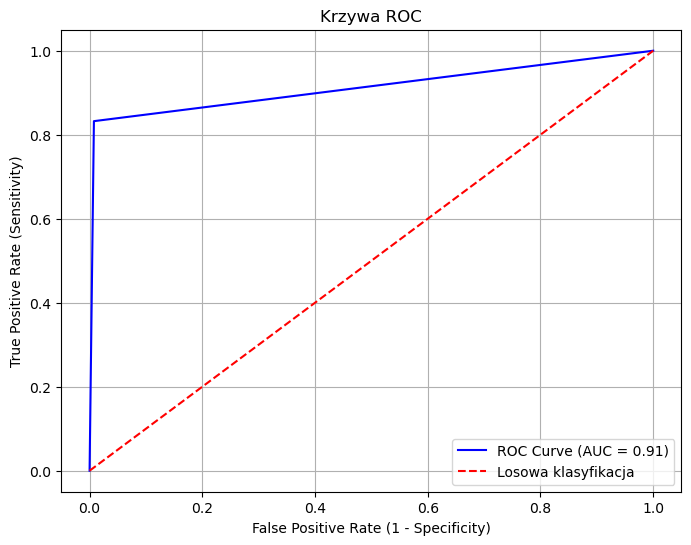

In [246]:
best_tree = grid_search.best_estimator_
best_tree.fit(X_train, y_train)
y_pred = best_tree.predict(X_test)

accuracy, sensitivity, specificity = calculate_metrics(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}, Sensitivity: {sensitivity:.2f}, Specificity: {specificity:.2f}")
plot_confusion_matrix(y_test, y_pred)
plot_roc_curve(y_test, y_pred)

## Zadanie na 5

Analiza wpływu głębokości drzewa na jego skuteczność

#### Sklearn

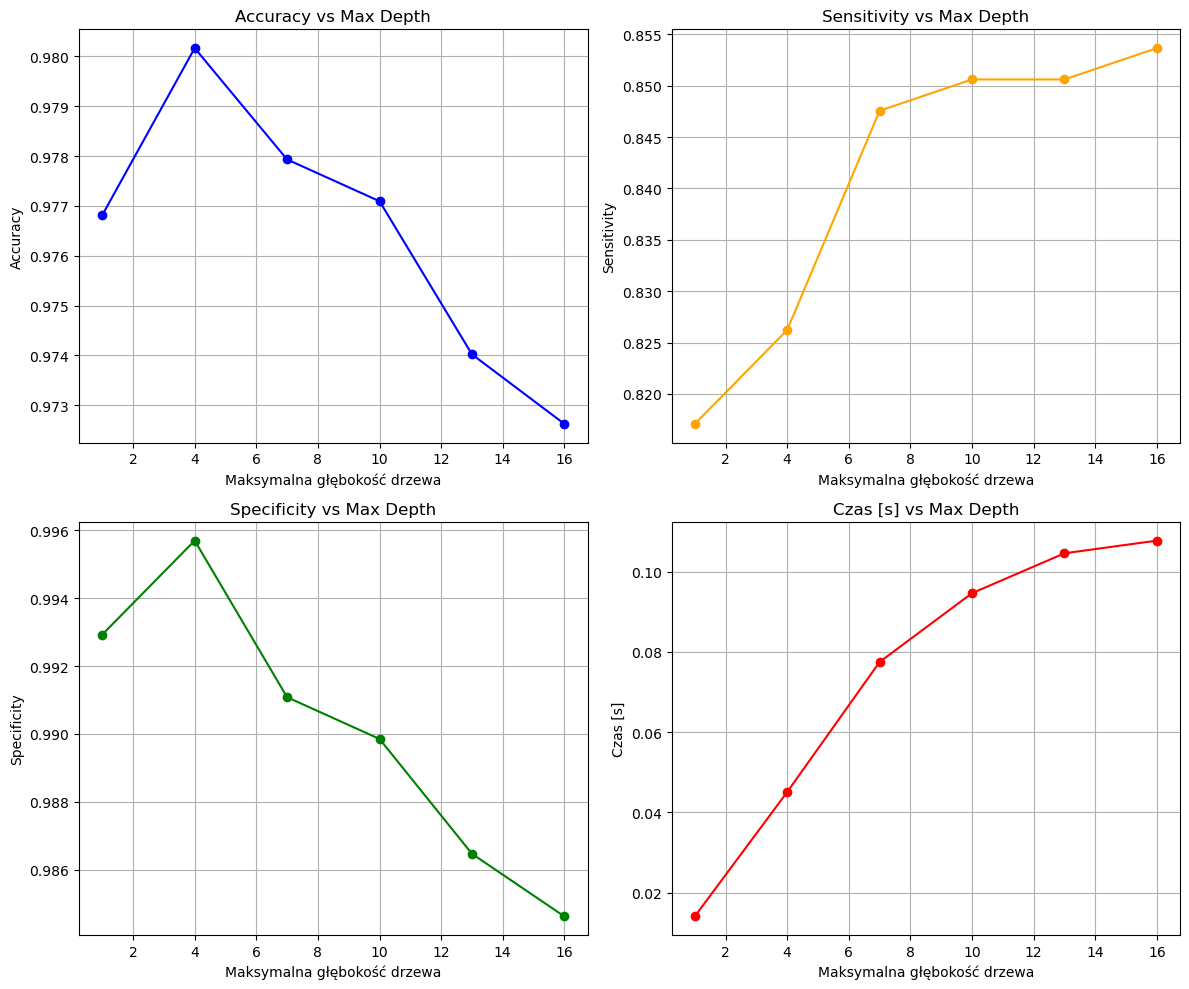

In [247]:
max_depths = range(1, 17, 3)

accuracies = []
sensitivities = []
specificities = []
speed = []

for depth in max_depths:
    times = []
    accs = []
    sens = []
    spec = []
    for _ in range(10):
        start_time = time.time()
        clf = DecisionTreeClassifier(max_depth=depth, random_state=my_index)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        elapsed = time.time() - start_time
        accuracy, sensitivity, specificity = calculate_metrics(y_test, y_pred)
        accs.append(accuracy)
        sens.append(sensitivity)
        spec.append(specificity)
        times.append(elapsed)
    accuracies.append(np.mean(accs))
    sensitivities.append(np.mean(sens))
    specificities.append(np.mean(spec))
    speed.append(np.mean(times))

plt.figure(figsize=(12, 10))

for i, (vals, label, color) in enumerate(zip(
    [accuracies, sensitivities, specificities, speed],
    ['Accuracy', 'Sensitivity', 'Specificity', 'Czas [s]'],
    ['b', 'orange', 'green', 'red'])):
    plt.subplot(2, 2, i+1)
    plt.plot(max_depths, vals, marker='o', color=color)
    plt.xlabel('Maksymalna głębokość drzewa')
    plt.ylabel(label)
    plt.title(f'{label} vs Max Depth')
    plt.grid(True)

plt.tight_layout()
plt.show()


#### Własna implementacja

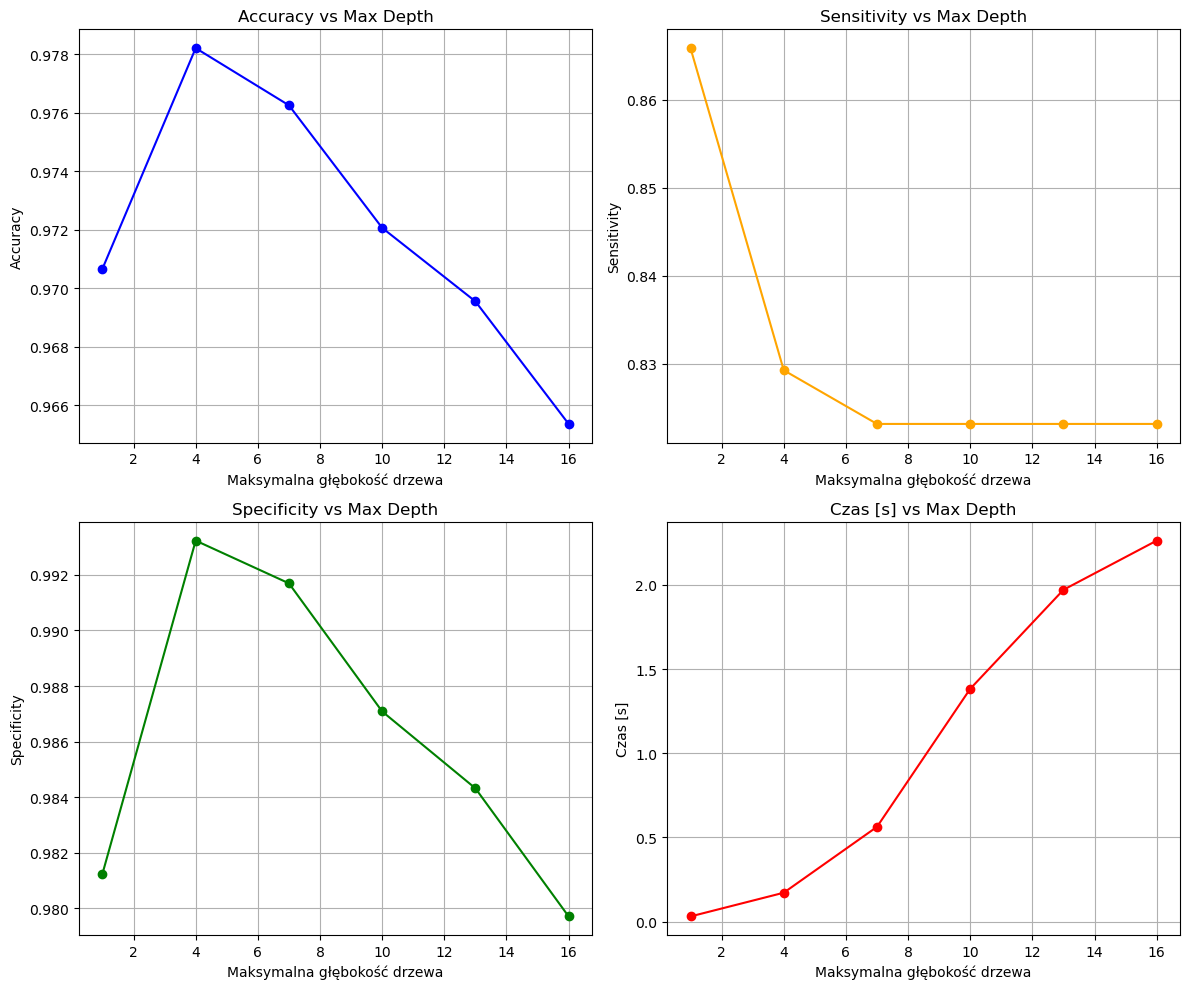

In [248]:
accuracies = []
sensitivities = []
specificities = []
speed = []

for depth in max_depths:
    times = []
    accs = []
    sens = []
    spec = []
    for _ in range(10):
        start_time = time.time()
        clf = DecisionTree(max_depth=depth)
        clf.fit(X_train.to_numpy(), y_train.to_numpy())
        y_pred = clf.predict(X_test.to_numpy())
        elapsed = time.time() - start_time
        accuracy, sensitivity, specificity = calculate_metrics(y_test, y_pred)
        accs.append(accuracy)
        sens.append(sensitivity)
        spec.append(specificity)
        times.append(elapsed)
    accuracies.append(np.mean(accs))
    sensitivities.append(np.mean(sens))
    specificities.append(np.mean(spec))
    speed.append(np.mean(times))

plt.figure(figsize=(12, 10))

for i, (vals, label, color) in enumerate(zip(
    [accuracies, sensitivities, specificities, speed],
    ['Accuracy', 'Sensitivity', 'Specificity', 'Czas [s]'],
    ['b', 'orange', 'green', 'red'])):
    plt.subplot(2, 2, i+1)
    plt.plot(max_depths, vals, marker='o', color=color)
    plt.xlabel('Maksymalna głębokość drzewa')
    plt.ylabel(label)
    plt.title(f'{label} vs Max Depth')
    plt.grid(True)

plt.tight_layout()
plt.show()


### Wnioski 

Czy wybierając cel dla pierwszej sondy mającej za zadanie zbadać pulsar z bliska uzasadniona jest optymalizaccja czasu uczenia i ewaluacji poprzez poszukiwanie optymalnej głębokości drzewa?

Tak